In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
# Pyplot rcparams
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = false;
mlines = pyimport("matplotlib").lines
# General method to give red-green-blue values for plotting
rgb(x, y, z) = [x, y, z] ./ 255

rgb (generic function with 1 method)

In [5]:
bn22bc_dir="./BN22BC"
bn22bc_buckled_dir="./BN22BC_Buckled"
bn33bc_dir="./BN33BC"
bn33bc_buckled_dir="./BN33BC_Buckled"
bn44bc_dir="./BN44BC"
bn44bc_buckled_dir="./BN44BC_Buckled"
bn22nc_dir="./BN22NC"
bn33nc_dir="./BN33NC"
bn44nc_dir="./BN44NC"
Ag_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/3Dnew"
Argentene_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/2Dnew"
graphene_dir = "./Graphene";

In [6]:
bn22bc_qs, bn22bc_plasmon, bn22bc_confinements = [x for x in eachcol(np.loadtxt(bn22bc_dir*"/Wannier/Plasmon.txt"))];
_, bn22bc_landau_lower, bn22bc_landau_upper = [x for x in eachcol(np.loadtxt(bn22bc_dir*"/Wannier/Landau.txt"))];
bn22nc_qs, bn22nc_plasmon, bn22nc_confinements = [x for x in eachcol(np.loadtxt(bn22nc_dir*"/Wannier/Plasmon.txt"))];
_, bn22nc_landau_lower, bn22nc_landau_upper = [x for x in eachcol(np.loadtxt(bn22nc_dir*"/Wannier/Landau.txt"))];

bn33bc_qs, bn33bc_plasmon, bn33bc_confinements = [x for x in eachcol(np.loadtxt(bn33bc_dir*"/Wannier/Plasmon.txt"))];
_, bn33bc_landau_lower, bn33bc_landau_upper = [x for x in eachcol(np.loadtxt(bn33bc_dir*"/Wannier/Landau.txt"))];
bn33nc_qs, bn33nc_plasmon, bn33nc_confinements = [x for x in eachcol(np.loadtxt(bn33nc_dir*"/Wannier/Plasmon.txt"))];
_, bn33nc_landau_lower, bn33nc_landau_upper = [x for x in eachcol(np.loadtxt(bn33nc_dir*"/Wannier/Landau.txt"))];

bn44bc_qs, bn44bc_plasmon, bn44bc_confinements = [x for x in eachcol(np.loadtxt(bn44bc_dir*"/Wannier/Plasmon.txt"))];
_, bn44bc_landau_lower, bn44bc_landau_upper = [x for x in eachcol(np.loadtxt(bn44bc_dir*"/Wannier/Landau.txt"))];
bn44nc_qs, bn44nc_plasmon, bn44nc_confinements = [x for x in eachcol(np.loadtxt(bn44nc_dir*"/Wannier/Plasmon.txt"))];
_, bn44nc_landau_lower, bn44nc_landau_upper = [x for x in eachcol(np.loadtxt(bn44nc_dir*"/Wannier/Landau.txt"))];

graphene_qs, graphene_plasmon, graphene_confinements = [x for x in eachcol(np.loadtxt(graphene_dir*"/Plasmon.txt"))];
_, graphene_landau_lower, graphene_landau_upper = [x for x in eachcol(np.loadtxt(graphene_dir*"/Landau.txt"))];

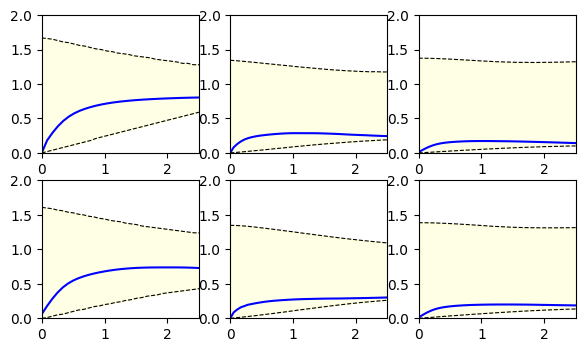

In [14]:
cm = 1/2.54
plasmon_color="blue"
graphene_color="green"
figure(figsize=(17.5*cm, 10*cm))
subplot(2, 3, 1)

plot(bn22bc_qs*10, bn22bc_plasmon, color=plasmon_color)
plot(bn22bc_qs*10, bn22bc_landau_lower, color="black", linestyle="dashed", linewidth=0.8)
plot(bn22bc_qs*10, bn22bc_landau_upper, color="black", linestyle="dashed", linewidth=0.8)
gca().fill_between(bn22bc_qs*10, bn22bc_landau_lower, bn22bc_landau_upper, alpha=0.1, color="yellow")

#plot(graphene_qs*10, graphene_plasmon, color=graphene_color)
#plot(graphene_qs[2:end]*10, graphene_landau_lower, color="red", linestyle="dashed", linewidth=0.8)
#plot(graphene_qs[2:end]*10, graphene_landau_upper, color="red", linestyle="dashed", linewidth=0.8)
xlim(0, 2.5)
ylim(0, 2)

subplot(2, 3, 2)
plot(bn33bc_qs*10, bn33bc_plasmon, color=plasmon_color)
plot(bn33bc_qs*10, bn33bc_landau_lower, color="black", linestyle="dashed", linewidth=0.8)
plot(bn33bc_qs*10, bn33bc_landau_upper, color="black", linestyle="dashed", linewidth=0.8)
gca().fill_between(bn33bc_qs*10, bn33bc_landau_lower, bn33bc_landau_upper, alpha=0.1, color="yellow")

#plot(graphene_qs*10, graphene_plasmon, color=graphene_color)
#plot(graphene_qs[2:end]*10, graphene_landau_lower, color="red", linestyle="dashed", linewidth=0.8)
#plot(graphene_qs[2:end]*10, graphene_landau_upper, color="red", linestyle="dashed", linewidth=0.8)

xlim(0, 2.5)
ylim(0, 2)

subplot(2, 3, 3)
plot(bn44bc_qs*10, bn44bc_plasmon, color=plasmon_color)
plot(bn44bc_qs*10, bn44bc_landau_lower, color="black", linestyle="dashed", linewidth=0.8)
plot(bn44bc_qs*10, bn44bc_landau_upper, color="black", linestyle="dashed", linewidth=0.8)
gca().fill_between(bn44bc_qs*10, bn44bc_landau_lower, bn44bc_landau_upper, alpha=0.1, color="yellow")

#plot(graphene_qs*10, graphene_plasmon, color=graphene_color)
#plot(graphene_qs[2:end]*10, graphene_landau_lower, color="red", linestyle="dashed", linewidth=0.8)
#plot(graphene_qs[2:end]*10, graphene_landau_upper, color="red", linestyle="dashed", linewidth=0.8)

xlim(0, 2.5)
ylim(0, 2)

subplot(2, 3, 4)
plot(bn22nc_qs*10, bn22nc_plasmon, color=plasmon_color)
plot(bn22nc_qs*10, bn22nc_landau_lower, color="black", linestyle="dashed", linewidth=0.8)
plot(bn22nc_qs*10, bn22nc_landau_upper, color="black", linestyle="dashed", linewidth=0.8)
gca().fill_between(bn22nc_qs*10, bn22nc_landau_lower, bn22nc_landau_upper, alpha=0.1, color="yellow")

#plot(graphene_qs*10, graphene_plasmon, color=graphene_color)
#plot(graphene_qs[2:end]*10, graphene_landau_lower, color="red", linestyle="dashed", linewidth=0.8)
#plot(graphene_qs[2:end]*10, graphene_landau_upper, color="red", linestyle="dashed", linewidth=0.8)

xlim(0, 2.5)
ylim(0, 2)

subplot(2, 3, 5)
plot(bn33nc_qs*10, bn33nc_plasmon, color=plasmon_color)
plot(bn33nc_qs*10, bn33nc_landau_lower, color="black", linestyle="dashed", linewidth=0.8)
plot(bn33nc_qs*10, bn33nc_landau_upper, color="black", linestyle="dashed", linewidth=0.8)
gca().fill_between(bn33nc_qs*10, bn33nc_landau_lower, bn33nc_landau_upper, alpha=0.1, color="yellow")

#plot(graphene_qs*10, graphene_plasmon, color=graphene_color)
#plot(graphene_qs[2:end]*10, graphene_landau_lower, color="red", linestyle="dashed", linewidth=0.8)
#plot(graphene_qs[2:end]*10, graphene_landau_upper, color="red", linestyle="dashed", linewidth=0.8)

xlim(0, 2.5)
ylim(0, 2)

subplot(2, 3, 6)
plot(bn44nc_qs*10, bn44nc_plasmon, color=plasmon_color)
plot(bn44nc_qs*10, bn44nc_landau_lower, color="black", linestyle="dashed", linewidth=0.8)
plot(bn44nc_qs*10, bn44nc_landau_upper, color="black", linestyle="dashed", linewidth=0.8)
gca().fill_between(bn44nc_qs*10, bn44nc_landau_lower, bn44nc_landau_upper, alpha=0.1, color="yellow")
#plot(graphene_qs*10, graphene_plasmon, color=graphene_color)
#plot(graphene_qs[2:end]*10, graphene_landau_lower, color="red", linestyle="dashed", linewidth=0.8)
#plot(graphene_qs[2:end]*10, graphene_landau_upper, color="red", linestyle="dashed", linewidth=0.8)

xlim(0, 2.5)
ylim(0, 2)
savefig("LandauDamping.pdf")